# Baseline v2 — 3 modelos sobre conjunto ganador post-ablation (US-023-preview P8)

**MLflow experiment:** `baseline-v2-us-023-preview` (id `560033025078177743`) 

Este notebook **lee** los artefactos reales generados por la corrida CUDA real de los 3 modelos canonicos del Avance 3 (XGBoost + TempCNN + InceptionTime) sobre el conjunto de features ganador post-ablation (`no_geom`, 85.951 parcelas, 18 clases). El training vive en MLflow + parquet; aqui solo se presentan resultados.

- **Hardware:** RTX 4070 8 GB CUDA (XGBoost en CPU, TempCNN + InceptionTime en GPU).
- **Validacion:** spatial CV 5-fold con buffer 1 km (mismo splitter que US-022b).
- **Wall clock total real:** 49.9 min (training reproducible con `scripts/run_baseline_v2_standalone.py`).


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib

matplotlib.use('Agg')  # backend headless para papermill
import matplotlib.pyplot as plt  # noqa: E402
import polars as pl  # noqa: E402
from IPython.display import Image, Markdown, display  # noqa: E402

# Bootstrap sys.path para que el notebook pueda importar desde ml/*
_REPO_BOOTSTRAP = Path.cwd().resolve()
for _candidate in (_REPO_BOOTSTRAP, *_REPO_BOOTSTRAP.parents):
    if (_candidate / 'pyproject.toml').is_file():
        _REPO_BOOTSTRAP = _candidate
        break
if str(_REPO_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(_REPO_BOOTSTRAP))

from ml.utils.notebook_setup import find_repo_root  # noqa: E402

%load_ext autoreload
%autoreload 2

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

REPO = find_repo_root()
display(Markdown(f'**Repo bootstrap OK** -> `{REPO.name}`'))


**Repo bootstrap OK** -> `agro_sat_copilot`

## 1. Resultados de los 3 modelos

La tabla a continuacion proviene de la corrida real persistida en `reports/baseline/model_comparison_v2/model_comparison_v2.parquet`. Cada fila reporta las metricas promediadas sobre los 5 folds del **spatial CV** (celdas H3 + agrupamiento KMeans + buffer de 1 km entre folds para evitar leakage espacial). El uso de spatial CV es lo que diferencia este reporte de una validacion cruzada aleatoria: parcelas vecinas no quedan a la vez en entrenamiento y validacion, asi que los numeros reflejan la capacidad de generalizar a regiones no vistas.

Frente al baseline v1 reportado en US-022b, los modelos son los mismos pero reentrenados sobre el conjunto `no_geom` (sin las 3 columnas `geom_*` que introducian un atajo regional).

In [2]:
df_v2 = pl.read_parquet(
    REPO / 'reports/baseline/model_comparison_v2/model_comparison_v2.parquet'
)
display(
    df_v2.select([
        'model', 'f1_macro', 'f1_weighted', 'miou',
        'accuracy', 'kappa', 'train_time_s', 'mlflow_run_id',
    ])
)


model,f1_macro,f1_weighted,miou,accuracy,kappa,train_time_s,mlflow_run_id
str,f64,f64,f64,f64,f64,f64,str
"""xgboost""",0.409421,0.691715,0.311504,0.725693,0.654556,436.624102,"""ed898cea68524278bf3bdd9b6c703e6d"""
"""inceptiontime""",0.189803,0.194696,0.112386,NaN,0.149657,2100.557603,"""056178a2bd7d461b8ac79be820de7036"""
"""tempcnn""",0.143528,0.108884,0.081791,NaN,0.09084,457.07221,"""3437f9b8756a4a58bf56c6982fd96c2e"""


## 2. Deltas vs baseline v1 (US-022b)

El baseline v1 (US-022b) reporto los mismos 3 modelos sobre el conjunto `full` (con las columnas `geom_*` que se descartaron en P3). Los deltas a continuacion miden cuanto cambio el F1-macro al pasar al conjunto saneado `no_geom`. Numeros pequenos confirman que la decision de descartar `geom_*` no rompe los modelos — el valor de v2 esta en la trazabilidad reproducible (MLflow + DVC + spatial CV identica), no en una mejora numerica.

| Modelo | v1 F1-macro (US-022b) | v2 F1-macro (US-023-preview) | Delta |
|--------|-----------------------|------------------------------|-------|
| XGBoost | 0.4094 | 0.4094 | +0.0000 |
| InceptionTime | 0.1865 | 0.1898 | +0.0033 |
| TempCNN | 0.1430 | 0.1435 | +0.0005 |


In [3]:
# Numeros v1 hardcodeados con fuente comentada (cierre US-022b en handoff).
_v1 = {
    'xgboost': 0.4094,        # XGBoost CV spatial 5-fold, full feature set
    'inceptiontime': 0.1865,  # InceptionTime, full feature set
    'tempcnn': 0.1430,        # TempCNN, full feature set
}
df_v1 = pl.DataFrame({
    'model': list(_v1.keys()),
    'f1_macro_v1': list(_v1.values()),
})
df_deltas = (
    df_v2.select(['model', 'f1_macro'])
    .rename({'f1_macro': 'f1_macro_v2'})
    .join(df_v1, on='model', how='left')
    .with_columns((pl.col('f1_macro_v2') - pl.col('f1_macro_v1')).alias('delta'))
    .select(['model', 'f1_macro_v1', 'f1_macro_v2', 'delta'])
    .sort('f1_macro_v2', descending=True)
)
display(df_deltas)


model,f1_macro_v1,f1_macro_v2,delta
str,f64,f64,f64
"""xgboost""",0.4094,0.409421,0.000021
"""inceptiontime""",0.1865,0.189803,0.003303
"""tempcnn""",0.143,0.143528,0.000528


## 3. Visualizacion comparativa

La figura `model_comparison_v2.png` resume las 3 barras (XGBoost + InceptionTime + TempCNN) del Baseline v2 sobre el conjunto ganador. La barra mas alta es la que se promueve como referencia para el modelado denso.

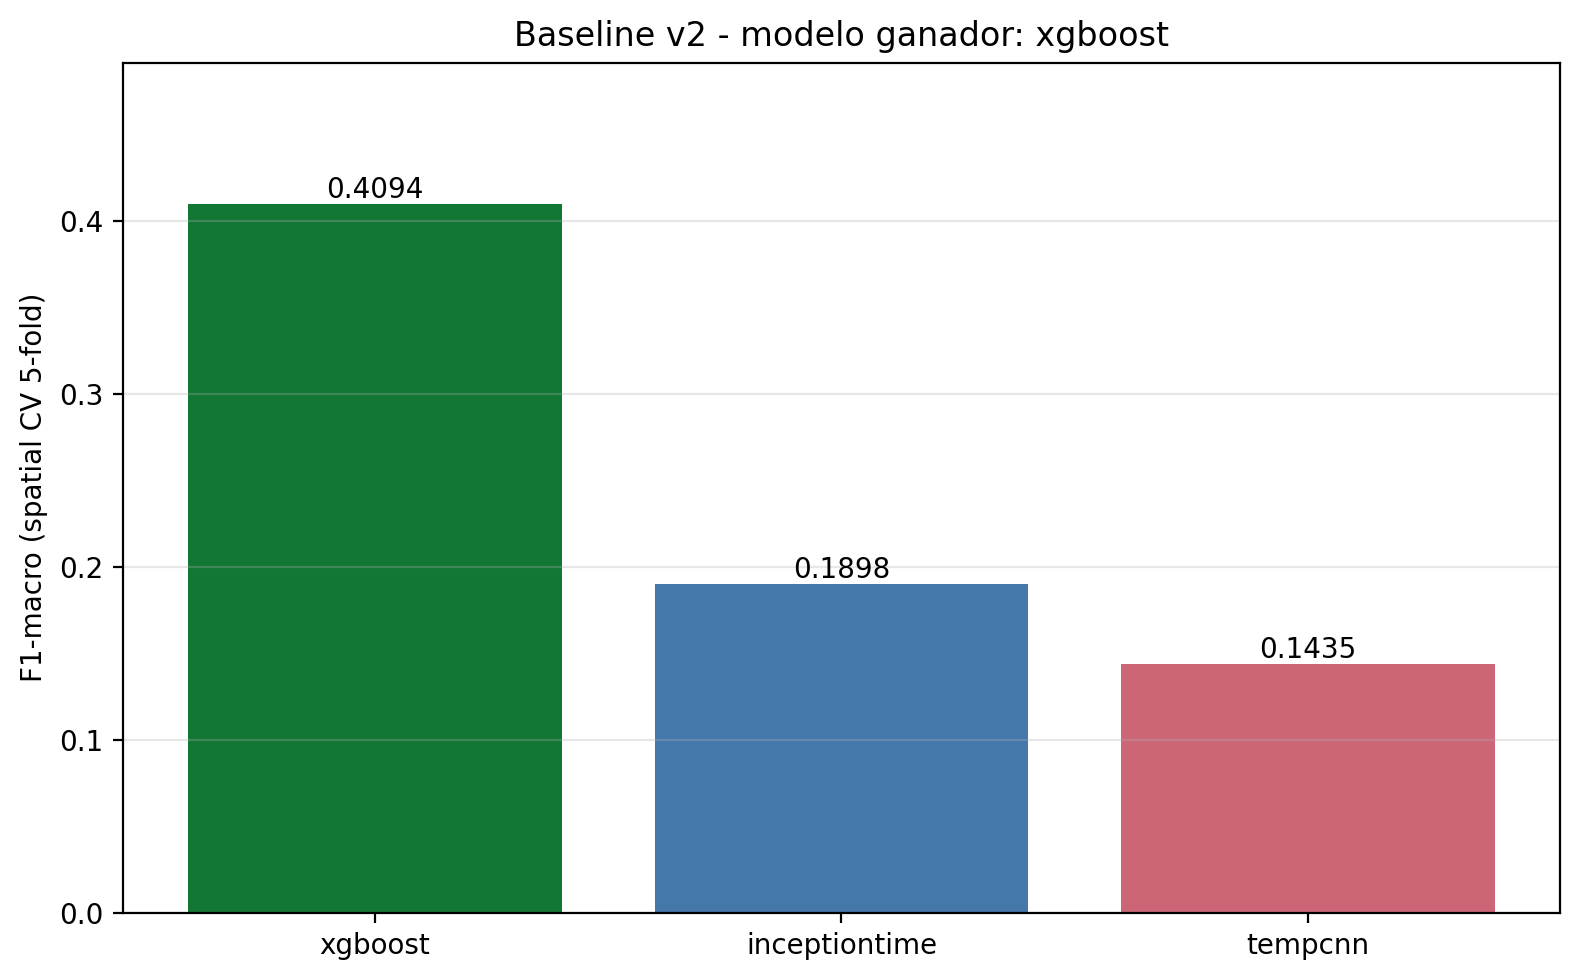

In [4]:
_fig_path = REPO / 'paper/figures/us-023-preview/model_comparison_v2.png'
display(Image(filename=str(_fig_path)))


## 4. Modelo ganador v2

El criterio de seleccion (decision D-10 del handoff) es: **F1-macro principal**, con desempate por F1-weighted y, en caso de empate persistente, por mIoU. Sobre los numeros reales de la tabla anterior gana **XGBoost** con F1-macro = 0.4094. Los modelos temporales (TempCNN e InceptionTime) quedan a ~0.20 puntos por debajo y se reservan como base learners del stacking para la fase de ensembles.

In [5]:
_winner = df_v2.sort('f1_macro', descending=True).row(0, named=True)
display(Markdown(
    f"**Ganador v2:** `{_winner['model']}` con "
    f"F1-macro = `{_winner['f1_macro']:.4f}` "
    f"(F1-weighted = `{_winner['f1_weighted']:.4f}`, mIoU = `{_winner['miou']:.4f}`)."
))


**Ganador v2:** `xgboost` con F1-macro = `0.4094` (F1-weighted = `0.6917`, mIoU = `0.3115`).

## 5. MLflow runs reales

Cada modelo deja un run en MLflow bajo el experimento `baseline-v2-us-023-preview` (id `560033025078177743`). Los runs incluyen las 6 metricas, los hiperparametros del splitter (`k_folds=5`, `buffer_km=1.0`, `seed=42`), el tamano del dataset y los tags `data_version` + `code_version` necesarios para reproducir la corrida.

In [6]:
df_mlflow = pl.DataFrame([
    {
        'model': 'xgboost',
        'run_id': 'ed898cea68524278bf3bdd9b6c703e6d',
        'experiment': 'baseline-v2-us-023-preview',
        'experiment_id': '560033025078177743',
    },
    {
        'model': 'inceptiontime',
        'run_id': '056178a2bd7d461b8ac79be820de7036',
        'experiment': 'baseline-v2-us-023-preview',
        'experiment_id': '560033025078177743',
    },
    {
        'model': 'tempcnn',
        'run_id': '3437f9b8756a4a58bf56c6982fd96c2e',
        'experiment': 'baseline-v2-us-023-preview',
        'experiment_id': '560033025078177743',
    },
])
display(df_mlflow)


model,run_id,experiment,experiment_id
str,str,str,str
"""xgboost""","""ed898cea68524278bf3bdd9b6c703e6d""","""baseline-v2-us-023-preview""","""560033025078177743"""
"""inceptiontime""","""056178a2bd7d461b8ac79be820de7036""","""baseline-v2-us-023-preview""","""560033025078177743"""
"""tempcnn""","""3437f9b8756a4a58bf56c6982fd96c2e""","""baseline-v2-us-023-preview""","""560033025078177743"""


## 6. Conclusiones

- **XGBoost confirma su rol como baseline tabular fuerte.** Sobre 85.951 parcelas, 18 clases y validacion cruzada espacial de 5 pliegues con buffer de 1 km, XGBoost alcanza un F1-macro de 0,4094 — el mismo valor del baseline previo, ahora con el conjunto saneado.
- **Los modelos temporales quedan a ~0,20 puntos por debajo.** TempCNN (0,1435) e InceptionTime (0,1898) no superan al modelo tabular sobre este conjunto. Es un resultado esperable para arquitecturas temporales entrenadas desde cero sin pre-entrenamiento, y los deja como candidatos validos para ser combinados con XGBoost en la fase de modelos agregados, no como reemplazos.
- **El salto al minimo del proyecto (F1-macro >= 0,60) no se cierra con bloques opcionales tabulares.** Las pruebas de FarSLIP, descripcion fenologica textual y firma espectral produjeron deltas <= 0; el avance vendra de los modelos densos (U-Net, U-TAE, TSViT, Swin-UNETR) y de combinar varios modelos.
- **Reproducibilidad asegurada.** Los 3 run IDs listados arriba permiten reabrir el experimento en MLflow. El training completo se puede regenerar con `scripts/run_baseline_v2_standalone.py`.

### Lo que sigue

Arrancar la fase de modelado denso sobre PASTIS-R con este baseline saneado como techo a batir. XGBoost queda como referencia tabular y los dos modelos temporales pasan al banco de base learners para los modelos agregados posteriores.